In [52]:
#imports
#from biblioteca.modulo import funcion
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sweetviz as sv
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
import statsmodels.api as sm
from statsmodels.tsa.arima.model import ARIMA



pd.set_option('display.max_columns', 200)

In [33]:
#importing day_csv data

day_csv = "data/day.csv"
day_df= pd.read_csv(day_csv)

In [34]:
report = sv.analyze(day_df)
report.show_html("report.html")

Feature: instant                             |▌         | [  6%]   00:00 -> (00:00 left)findfont: Failed to find font weight normal, now using 500.
findfont: Failed to find font weight normal, now using 500.
findfont: Failed to find font weight normal, now using 500.
findfont: Failed to find font weight normal, now using 500.
findfont: Failed to find font weight normal, now using 500.
findfont: Failed to find font weight normal, now using 500.
findfont: Failed to find font weight normal, now using 500.
findfont: Failed to find font weight normal, now using 500.
findfont: Failed to find font weight normal, now using 500.
findfont: Failed to find font weight normal, now using 500.
Feature: season                              |█▊        | [ 18%]   00:01 -> (00:11 left)findfont: Failed to find font weight normal, now using 500.
findfont: Failed to find font weight normal, now using 500.
findfont: Failed to find font weight normal, now using 500.
findfont: Failed to find font weight normal,

Report report.html was generated! NOTEBOOK/COLAB USERS: the web browser MAY not pop up, regardless, the report IS saved in your notebook/colab files.


DAY_CSV DATA UNDERSTANDING

In [ ]:
day_df.dtypes

In [ ]:
day_df.describe()

In [ ]:
day_df.head(20)

In [ ]:
day_df.isna().sum()

In [35]:
#importing hour_csv data
hour_csv = "data/hour.csv"
hour_df = pd.read_csv(hour_csv)

HOUR_CSV DATA UNDERSTANDING

In [ ]:
report_hour = sv.analyze(hour_df)
report_hour.show_html("report.html")

In [ ]:
hour_df.shape

In [ ]:
hour_df.dtypes

In [ ]:
hour_df.describe()

In [ ]:
hour_df.head()

In [ ]:
hour_df.isna().sum()

DATA CLEANING

In [ ]:
#no duplicated values
print(f'Valores duplicados en day_csv: {day_df.duplicated().sum()}')
print(f'Valores duplicados en hour_csv: {hour_df.duplicated().sum()}')

In [36]:
#transforming dteday into datetime
day_df['dteday'] = pd.to_datetime(day_df['dteday'])
display(day_df['dteday'].describe())
hour_df['dteday'] = pd.to_datetime(hour_df['dteday'])
display(hour_df['dteday'].describe())

count                    731
mean     2012-01-01 00:00:00
min      2011-01-01 00:00:00
25%      2011-07-02 12:00:00
50%      2012-01-01 00:00:00
75%      2012-07-01 12:00:00
max      2012-12-31 00:00:00
Name: dteday, dtype: object

count                         17379
mean     2012-01-02 04:08:34.552045
min             2011-01-01 00:00:00
25%             2011-07-04 00:00:00
50%             2012-01-02 00:00:00
75%             2012-07-02 00:00:00
max             2012-12-31 00:00:00
Name: dteday, dtype: object

In [38]:
#renaming columns and dropping somes
day_df = day_df.rename(columns={'dteday':'date',
                       'weathersit':'weather',
                       'yr':'year',
                       'mnth':'month',
                       'cnt':'rented_bikes'
                       })

In [39]:
hour_df = hour_df.rename(columns={'dteday':'date',
                       'weathersit':'weather',
                       'yr':'year',
                       'mnth':'month',
                       'cnt':'rented_bikes',
                       'hr':'hour'
                       })

In [ ]:
#exploratory data analysis
#there's missing hours on our dataset. We need a complete dataset if we want a model working properly

# 1. create a new column combining date and time. We use timedelta because to a timestamp we can only add duration
hour_df['datetime'] = pd.to_datetime(hour_df['date']) + pd.to_timedelta(hour_df['hour'], unit='h')

# 2. create the perfect range
complete_range = pd.date_range(
    start=hour_df['datetime'].min(), 
    end=hour_df['datetime'].max(), 
    freq='h' # 'h' means hourly frequency
)
    
# 3. we do difference to subtract the new column values to our perfect range (complete calendar)
#we do this because we need to know how many hours are we missing, so we can index them perfectly
missing_hours = complete_range.difference(hour_df['datetime']) 

# --- SHOW RESULTS ---
print(f"all missing hours detected: {len(missing_hours)}")
display(missing_hours[:10]) #we show the first 10 so we see everything is ok

# 4. indexing the new data. This will generate len(missing_hours) rows with NaN as a value for all of them
hour_df_reindex = hour_df.set_index('datetime')
completed_hour_df = hour_df_reindex.reindex(complete_range)

# 5. refilling data 
final_hour_df = completed_hour_df.copy()
#numerical_cols are the columns that only have numerical values (temperature, humidity...)
numerical_cols = completed_hour_df.select_dtypes(include=['number']).columns 
#interpolate only numerical columns
final_hour_df[numerical_cols] = completed_hour_df[numerical_cols].interpolate(method='time')
#fill not numerical columns so we dont break the model. This takes previous column text and put it on the empty next one
final_hour_df = final_hour_df.ffill()


In [62]:
#we create a general configuration for our graphics
sns.set_theme (
    style = 'whitegrid',
    palette = 'muted',
    context = 'talk',
    rc = {
        'figure.figsize' : (8,5),
        'axes.titlesize' : 16,
        'axes.labelsize' : 12
    },
)

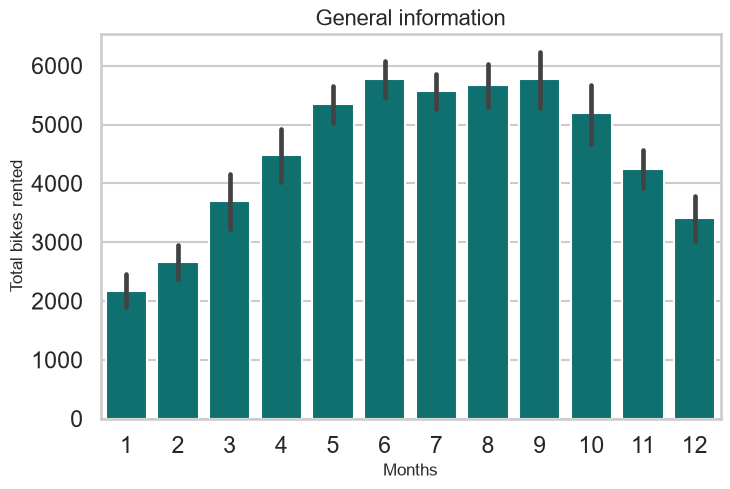

In [63]:
#first, histogram

sns.barplot(data=day_df, x='month', y='rented_bikes', color = 'teal')

plt.title('General information')
plt.xlabel('Months') 
plt.ylabel('Total bikes rented')
plt.show()

In [ ]:
final_hour_df.columns

In [ ]:
display(final_hour_df.head())

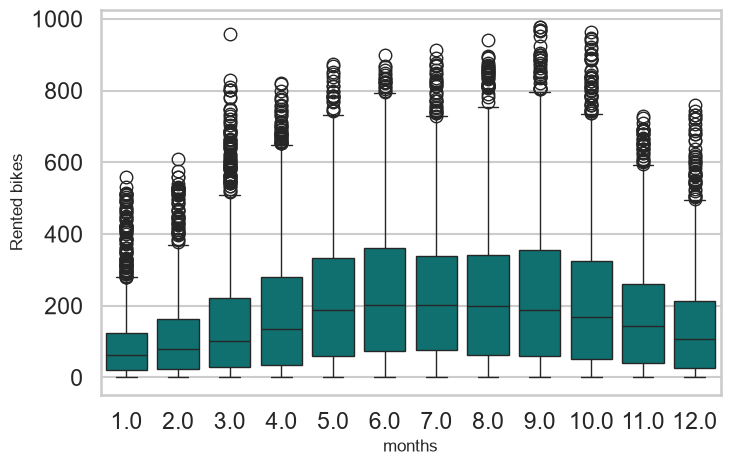

In [ ]:
#searching for outliers. The best way is creating a boxplot

clean_hours = final_hour_df.index.hour
ax = sns.boxplot(data=final_hour_df, x='month', y='rented_bikes', color = 'teal')
plt.xlabel('months')
plt.ylabel('Rented bikes')
plt.show()


In [ ]:
day_df.columns

In [ ]:

#PASO 2. CUMPLIR CON LOS REQUISITOS DE PANDAS
#índice: DatetimeIndex
#asegurar orden cronológico
#asegurar frecuencia constante

#índice
day_df = day_df.set_index('date').sort_index() #establecemos índice y orden cronológico
day_df = day_df.asfreq('D') #frecuencia

In [31]:
#para comprobar que todo ha funcionado bien:
#day_df.head()
#type(day_df.index)
day_df.index.freq

<Day>

Text(0.5, 1.0, 'Resid')

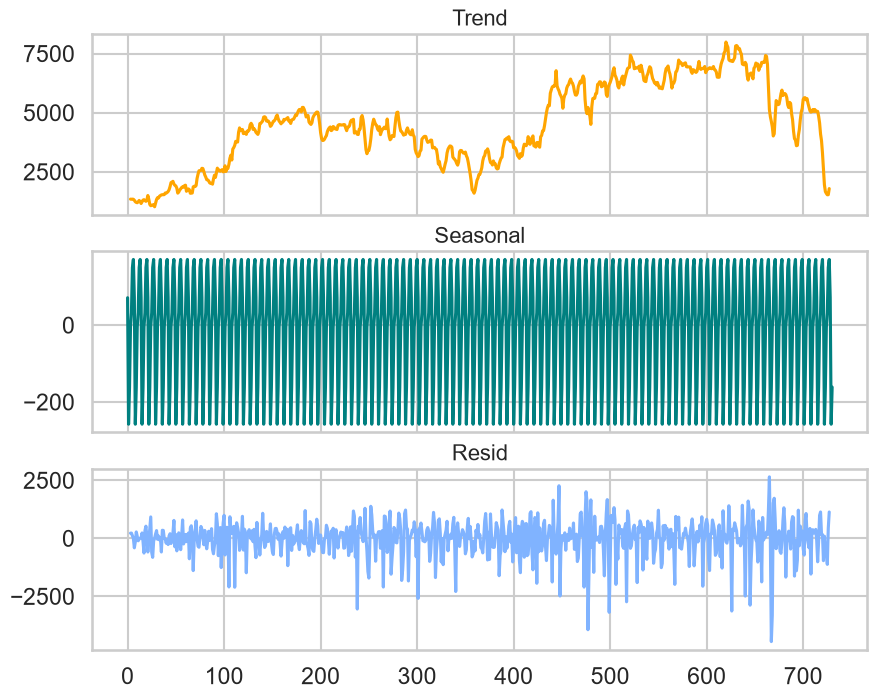

In [81]:
#Definición de la serie temporal. Gráficos que demuestren la temporalidad. Buscar tendencia y estacionalidad.
res_semanal = seasonal_decompose(day_df['rented_bikes'], model='additive', period=7)
fig, (ax1, ax2, ax3) = plt.subplots(3,1, figsize=(10, 8), sharex=True)
res_semanal.trend.plot(ax=ax1, color='orange')
ax1.set_title("Trend")
res_semanal.seasonal.plot(ax=ax2, color='teal')
ax2.set_title("Seasonal")
res_semanal.resid.plot(ax=ax3, color="#80B3FF")
ax3.set_title("Resid")


Text(0.5, 1.0, 'Resid')

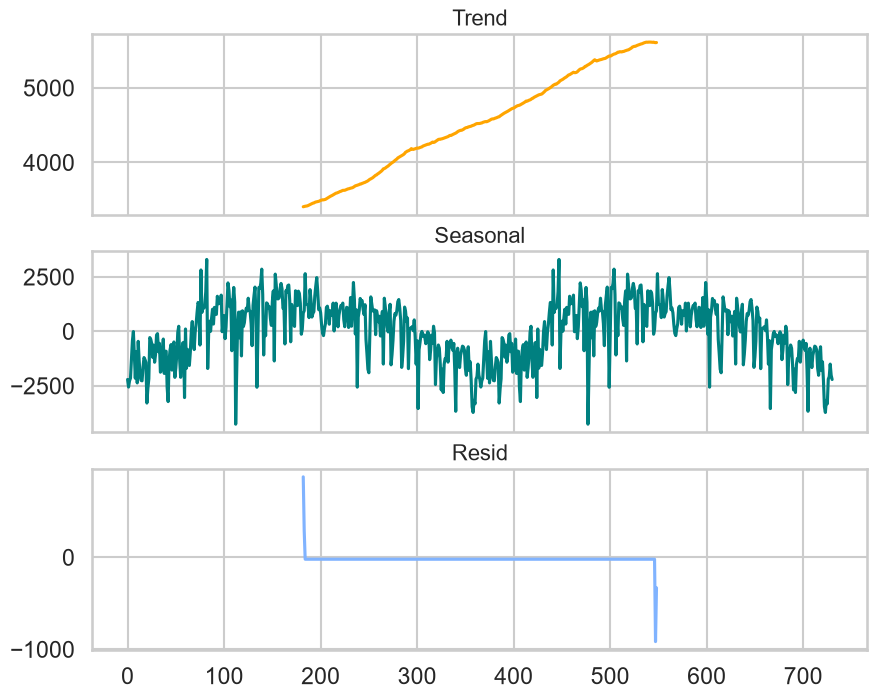

In [82]:
res_anual = seasonal_decompose(day_df['rented_bikes'], model='additive', period=365)
fig, (ax1, ax2, ax3) = plt.subplots(3,1, figsize=(10, 8), sharex=True)
res_anual.trend.plot(ax=ax1, color='orange')
ax1.set_title("Trend")
res_anual.seasonal.plot(ax=ax2, color='teal')
ax2.set_title("Seasonal")
res_anual.resid.plot(ax=ax3, color="#80B3FF")
ax3.set_title("Resid")

Vale, el trend sale así porque, para calcular correctamente la tendencia anual, el algoritmo necesita mirar un año hacia atrás y un año hacia adelante en cada punto para hacer una media móvil. Como en nuestro dataset solamente tiene datos durante dos años, (730 días en el eje x), la función pierde los primeros y últimos 180 días porque no tiene ni presente ni futuro suficiente para calcular la media anual. Sin embargo, vemos un crecimiento limpio y constante.

In [ ]:
#Transformaciones de la serie


In [ ]:
#Función de autocorrelación simple (ACF) y parcial (PACF)